In [1]:
"""
PROTAC Compound Similarity Analysis
Порівняння сполук з двох файлів за допомогою Tanimoto similarity та інших метрик.

Залежності: rdkit, pandas, numpy, matplotlib, seaborn
    pip install rdkit pandas numpy matplotlib seaborn
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

# ─── Налаштування ─────────────────────────────────────────────────────────────

FILE_A = "../data/link_invent_outputs/BRD4_protacs.csv"
FILE_B = "../data/link_invent_outputs/sampling_test_protac_active_full_3.csv"

# Назви колонок зі SMILES у кожному файлі
SMILES_COL_A = "mol"    # BRD4_protacs.csv
SMILES_COL_B = "SMILES" # sampling_test_protac_active_full_3.csv

MORGAN_RADIUS   = 2     # радіус Morgan fingerprint (ECFP4)
MORGAN_NBITS    = 2048  # розмір бітового вектора
TANIMOTO_THRESH = 0.7   # поріг для «схожих» сполук
DUPLICATE_THRESH = 1.0  # поріг для «однакових» (точні дублікати)

OUTPUT_DIR = Path("similarity_output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# ─── Допоміжні функції ────────────────────────────────────────────────────────

def load_mols(path: str, label: str, smiles_col: str):
    df = pd.read_csv(path)
    print(f"\n[{label}] Завантажено {len(df)} рядків, колонки: {list(df.columns)}")
    col = smiles_col
    print(f"[{label}] Використовується колонка SMILES: '{col}'")

    smiles_list, mols, valid_idx = [], [], []
    for i, smi in enumerate(df[col]):
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            smiles_list.append(Chem.MolToSmiles(mol))  # канонічний SMILES
            mols.append(mol)
            valid_idx.append(i)

    df_valid = df.iloc[valid_idx].copy()
    df_valid["canonical_smiles"] = smiles_list
    print(f"[{label}] Валідних молекул: {len(mols)} / {len(df)}")
    return df_valid, mols, smiles_list


_morgan_gen = AllChem.GetMorganGenerator(radius=MORGAN_RADIUS, fpSize=MORGAN_NBITS)

def get_fps(mols):
    return [_morgan_gen.GetFingerprint(m) for m in mols]


def calc_descriptors(mol):
    return {
        "MW":    Descriptors.MolWt(mol),
        "LogP":  Descriptors.MolLogP(mol),
        "HBD":   rdMolDescriptors.CalcNumHBD(mol),
        "HBA":   rdMolDescriptors.CalcNumHBA(mol),
        "TPSA":  Descriptors.TPSA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
    }


def murcko_scaffold(mol):
    try:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    except Exception:
        return None

In [3]:
# ─── Завантаження даних ───────────────────────────────────────────────────────

df_a, mols_a, smi_a = load_mols(FILE_A, "BRD4_protacs", SMILES_COL_A)
df_b, mols_b, smi_b = load_mols(FILE_B, "sampling_test", SMILES_COL_B)

fps_a = get_fps(mols_a)
fps_b = get_fps(mols_b)


[BRD4_protacs] Завантажено 182 рядків, колонки: ['protac_name', 'min_energy', 'max_energy', 'avg_energy', 'median_energy', 'mol', 'model', 'BRD4', 'CBRB']
[BRD4_protacs] Використовується колонка SMILES: 'mol'
[BRD4_protacs] Валідних молекул: 182 / 182

[sampling_test] Завантажено 766 рядків, колонки: ['SMILES', 'SMILES_state', 'Warheads', 'Linker', 'NLL']
[sampling_test] Використовується колонка SMILES: 'SMILES'
[sampling_test] Валідних молекул: 766 / 766


In [4]:
# ─── 1. Пошук точних дублікатів (InChI / canonical SMILES) ───────────────────

print("\n" + "="*60)
print("1. ПОШУК ТОЧНИХ ДУБЛІКАТІВ")
print("="*60)

set_a = set(smi_a)
set_b = set(smi_b)
duplicates = set_a & set_b

print(f"  Унікальних у файлі A: {len(set_a)}")
print(f"  Унікальних у файлі B: {len(set_b)}")
print(f"  Точних збігів (Tanimoto=1.0): {len(duplicates)}")

if duplicates:
    dup_df = pd.DataFrame(sorted(duplicates), columns=["canonical_smiles"])
    dup_df.to_csv(OUTPUT_DIR / "exact_duplicates.csv", index=False)
    print(f"  Збережено у: {OUTPUT_DIR / 'exact_duplicates.csv'}")
    for s in list(duplicates)[:5]:
        print(f"    {s[:80]}...")


1. ПОШУК ТОЧНИХ ДУБЛІКАТІВ
  Унікальних у файлі A: 182
  Унікальних у файлі B: 766
  Точних збігів (Tanimoto=1.0): 0


In [5]:
# ─── 2. Матриця Tanimoto (A vs B) ─────────────────────────────────────────────

print("\n" + "="*60)
print("2. ПОПАРНА TANIMOTO SIMILARITY (A vs B)")
print("="*60)

# Для великих датасетів рахуємо найкращий збіг для кожної молекули A
best_match = []   # (idx_a, idx_b, tanimoto)
all_max_sim = []

for i, fp_a in enumerate(fps_a):
    sims = DataStructs.BulkTanimotoSimilarity(fp_a, fps_b)
    best_j = int(np.argmax(sims))
    best_sim = sims[best_j]
    best_match.append((i, best_j, best_sim))
    all_max_sim.append(best_sim)

all_max_sim = np.array(all_max_sim)

print(f"  Середня max-Tanimoto (A→B): {all_max_sim.mean():.3f}")
print(f"  Медіана:                    {np.median(all_max_sim):.3f}")
print(f"  Мін / Макс:                 {all_max_sim.min():.3f} / {all_max_sim.max():.3f}")
print(f"  Схожих (≥{TANIMOTO_THRESH}):              {(all_max_sim >= TANIMOTO_THRESH).sum()} / {len(all_max_sim)}")
print(f"  Ідентичних (=1.0):          {(all_max_sim == 1.0).sum()}")

# Зберігаємо таблицю найкращих збігів
match_records = []
for i, j, sim in best_match:
    match_records.append({
        "smiles_A":      smi_a[i],
        "smiles_B_best": smi_b[j],
        "tanimoto":      round(sim, 4),
    })
match_df = pd.DataFrame(match_records).sort_values("tanimoto", ascending=False)
match_df.to_csv(OUTPUT_DIR / "best_matches_A_to_B.csv", index=False)
print(f"  Таблиця збережена: {OUTPUT_DIR / 'best_matches_A_to_B.csv'}")




2. ПОПАРНА TANIMOTO SIMILARITY (A vs B)
  Середня max-Tanimoto (A→B): 0.499
  Медіана:                    0.500
  Мін / Макс:                 0.333 / 0.692
  Схожих (≥0.7):              0 / 182
  Ідентичних (=1.0):          0
  Таблиця збережена: similarity_output/best_matches_A_to_B.csv


In [6]:
# ─── 3. Дескриптори ───────────────────────────────────────────────────────────

print("\n" + "="*60)
print("3. ФІЗИКО-ХІМІЧНІ ДЕСКРИПТОРИ")
print("="*60)

desc_a = pd.DataFrame([calc_descriptors(m) for m in mols_a])
desc_b = pd.DataFrame([calc_descriptors(m) for m in mols_b])

for col in desc_a.columns:
    print(f"\n  {col}:")
    print(f"    A — mean={desc_a[col].mean():.2f}, std={desc_a[col].std():.2f}, "
          f"[{desc_a[col].min():.1f} – {desc_a[col].max():.1f}]")
    print(f"    B — mean={desc_b[col].mean():.2f}, std={desc_b[col].std():.2f}, "
          f"[{desc_b[col].min():.1f} – {desc_b[col].max():.1f}]")


3. ФІЗИКО-ХІМІЧНІ ДЕСКРИПТОРИ

  MW:
    A — mean=741.72, std=45.81, [626.7 – 905.0]
    B — mean=846.00, std=40.31, [674.6 – 1003.2]

  LogP:
    A — mean=2.21, std=0.92, [-0.1 – 4.2]
    B — mean=5.04, std=1.13, [1.2 – 8.7]

  HBD:
    A — mean=4.11, std=0.81, [2.0 – 5.0]
    B — mean=3.28, std=0.86, [2.0 – 6.0]

  HBA:
    A — mean=10.26, std=1.75, [7.0 – 16.0]
    B — mean=12.21, std=1.83, [8.0 – 17.0]

  TPSA:
    A — mean=204.98, std=17.47, [163.1 – 247.9]
    B — mean=202.27, std=18.07, [151.6 – 261.4]

  RotBonds:
    A — mean=12.52, std=2.86, [6.0 – 23.0]
    B — mean=10.22, std=1.11, [7.0 – 16.0]

  Rings:
    A — mean=6.31, std=0.82, [5.0 – 8.0]
    B — mean=8.47, std=0.53, [7.0 – 10.0]

  HeavyAtoms:
    A — mean=52.79, std=3.28, [45.0 – 64.0]
    B — mean=59.72, std=2.84, [48.0 – 70.0]


In [7]:
# ─── 4. Murcko Scaffolds ──────────────────────────────────────────────────────

print("\n" + "="*60)
print("4. MURCKO SCAFFOLDS")
print("="*60)

scaffolds_a = [murcko_scaffold(m) for m in mols_a]
scaffolds_b = [murcko_scaffold(m) for m in mols_b]

uniq_a = set(s for s in scaffolds_a if s)
uniq_b = set(s for s in scaffolds_b if s)
shared_scaffolds = uniq_a & uniq_b

print(f"  Унікальних скаффолдів у A: {len(uniq_a)}")
print(f"  Унікальних скаффолдів у B: {len(uniq_b)}")
print(f"  Спільних скаффолдів:       {len(shared_scaffolds)}")

scaf_df = pd.DataFrame({
    "scaffold": list(uniq_a | uniq_b),
    "in_A": [s in uniq_a for s in uniq_a | uniq_b],
    "in_B": [s in uniq_b for s in uniq_a | uniq_b],
})
scaf_df.to_csv(OUTPUT_DIR / "scaffolds.csv", index=False)


4. MURCKO SCAFFOLDS
  Унікальних скаффолдів у A: 182
  Унікальних скаффолдів у B: 727
  Спільних скаффолдів:       0


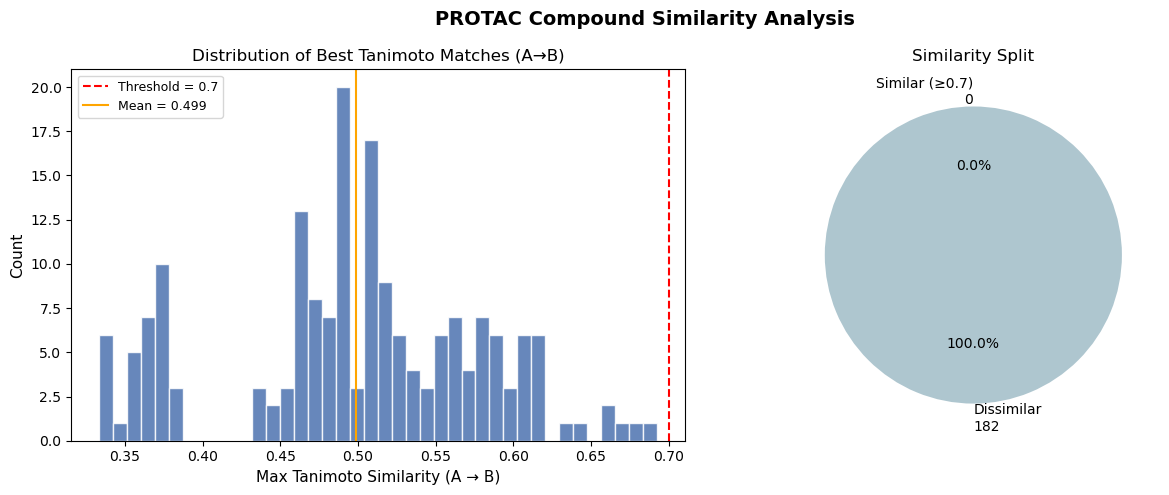

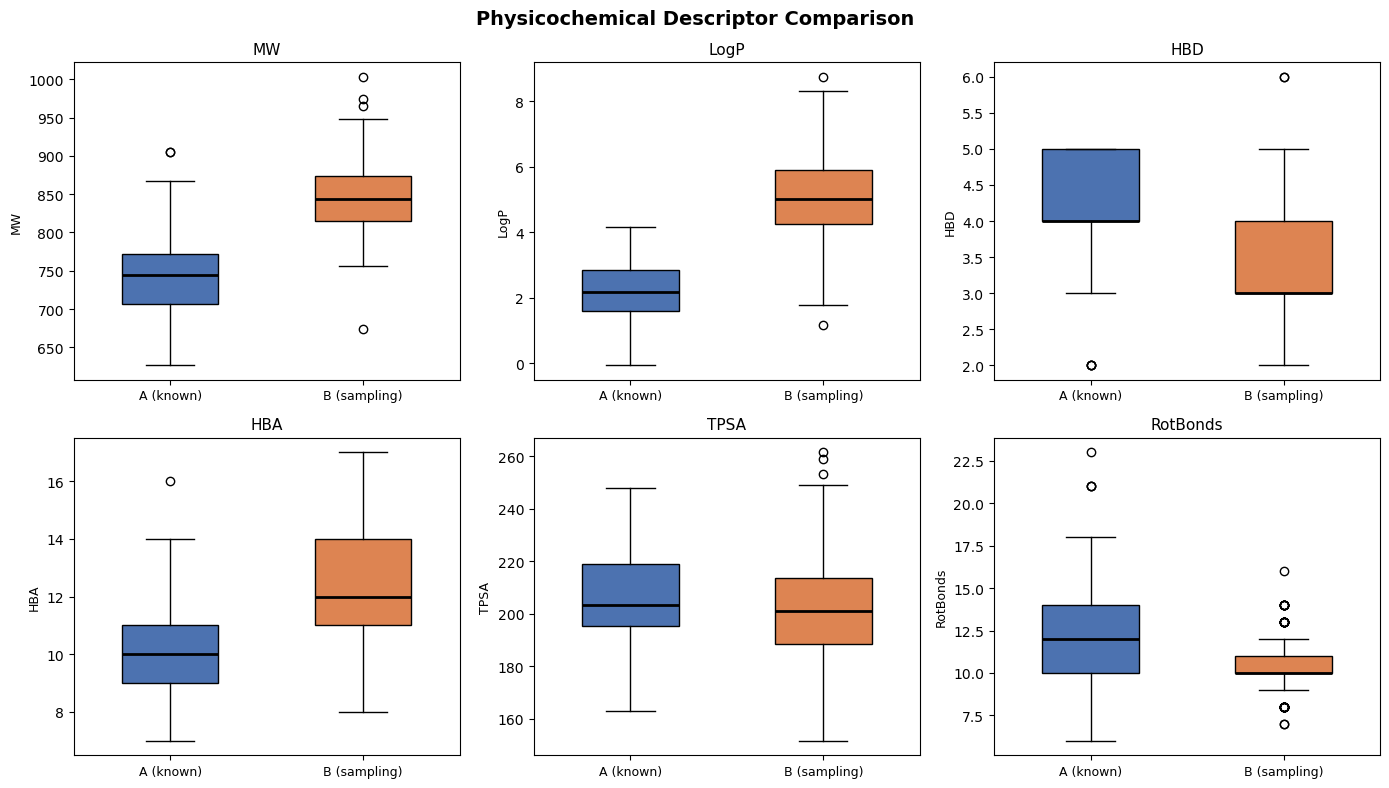

In [8]:
# ─── 5. Візуалізація ──────────────────────────────────────────────────────────

COLORS = {"A": "#4C72B0", "B": "#DD8452"}
similar = (all_max_sim >= TANIMOTO_THRESH).sum()

# ── Фігура 1: Tanimoto розподіл + pie ────────────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle("PROTAC Compound Similarity Analysis", fontsize=14, fontweight="bold")

ax1.hist(all_max_sim, bins=40, color=COLORS["A"], edgecolor="white", alpha=0.85)
ax1.axvline(TANIMOTO_THRESH, color="red", linestyle="--", lw=1.5,
            label=f"Threshold = {TANIMOTO_THRESH}")
ax1.axvline(all_max_sim.mean(), color="orange", linestyle="-", lw=1.5,
            label=f"Mean = {all_max_sim.mean():.3f}")
ax1.set_xlabel("Max Tanimoto Similarity (A → B)", fontsize=11)
ax1.set_ylabel("Count", fontsize=11)
ax1.set_title("Distribution of Best Tanimoto Matches (A→B)", fontsize=12)
ax1.legend(fontsize=9)

counts = [similar, len(all_max_sim) - similar]
labels = [f"Similar (≥{TANIMOTO_THRESH})\n{similar}",
          f"Dissimilar\n{len(all_max_sim) - similar}"]
ax2.pie(counts, labels=labels, colors=[COLORS["A"], "#aec6cf"],
        autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
ax2.set_title("Similarity Split", fontsize=12)

fig1.tight_layout()
fig1.savefig(OUTPUT_DIR / "tanimoto_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig1)

# ── Фігура 2: Дескриптори ─────────────────────────────────────────────────────
desc_cols = ["MW", "LogP", "HBD", "HBA", "TPSA", "RotBonds"]
fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
fig2.suptitle("Physicochemical Descriptor Comparison", fontsize=14, fontweight="bold")

for ax, col in zip(axes2.flat, desc_cols):
    bp = ax.boxplot([desc_a[col].values, desc_b[col].values],
                    patch_artist=True, widths=0.5,
                    medianprops={"color": "black", "lw": 2})
    bp["boxes"][0].set_facecolor(COLORS["A"])
    bp["boxes"][1].set_facecolor(COLORS["B"])
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["A (known)", "B (sampling)"], fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel(col, fontsize=9)

fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "descriptors_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig2)

In [9]:
# ─── Фінальні метрики ─────────────────────────────────────────────────────────

# Heatmap підмножини (перші 30×30)
N = min(30, len(fps_a), len(fps_b))
sim_matrix = np.zeros((N, N))
for i in range(N):
    sims = DataStructs.BulkTanimotoSimilarity(fps_a[i], fps_b[:N])
    sim_matrix[i] = sims

fig3, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, ax=ax, cmap="YlOrRd", vmin=0, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Tanimoto Similarity"})
ax.set_xlabel("File B (sampling_test) — first 30", fontsize=11)
ax.set_ylabel("File A (BRD4_protacs) — first 30", fontsize=11)
ax.set_title(f"Tanimoto Similarity Heatmap (first {N}×{N})", fontsize=13)
fig3.tight_layout()
fig3.savefig(OUTPUT_DIR / "tanimoto_heatmap.png", dpi=150, bbox_inches="tight")
plt.close(fig3)
print(f"\n  Heatmap збережено: {OUTPUT_DIR / 'tanimoto_heatmap.png'}")

# ─── Підсумок ─────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("ПІДСУМОК")
print("="*60)
summary = {
    "n_compounds_A":             len(mols_a),
    "n_compounds_B":             len(mols_b),
    "exact_duplicates":          len(duplicates),
    "similar_pairs_thr":         int((all_max_sim >= TANIMOTO_THRESH).sum()),
    "mean_max_tanimoto_A_to_B":  round(float(all_max_sim.mean()), 4),
    "median_max_tanimoto_A_to_B": round(float(np.median(all_max_sim)), 4),
    "unique_scaffolds_A":        len(uniq_a),
    "unique_scaffolds_B":        len(uniq_b),
    "shared_scaffolds":          len(shared_scaffolds),
}
for k, v in summary.items():
    print(f"  {k:<35} {v}")

pd.DataFrame([summary]).to_csv(OUTPUT_DIR / "summary.csv", index=False)
print(f"\nВсі результати збережені у: {OUTPUT_DIR}/")
print("  - best_matches_A_to_B.csv")
print("  - exact_duplicates.csv")
print("  - scaffolds.csv")
print("  - tanimoto_heatmap.png")
print("  - descriptors_boxplot.png")
print("  - summary.csv")


  Heatmap збережено: similarity_output/tanimoto_heatmap.png

ПІДСУМОК
  n_compounds_A                       182
  n_compounds_B                       766
  exact_duplicates                    0
  similar_pairs_thr                   0
  mean_max_tanimoto_A_to_B            0.4988
  median_max_tanimoto_A_to_B          0.5
  unique_scaffolds_A                  182
  unique_scaffolds_B                  727
  shared_scaffolds                    0

Всі результати збережені у: similarity_output/
  - best_matches_A_to_B.csv
  - exact_duplicates.csv
  - scaffolds.csv
  - tanimoto_heatmap.png
  - descriptors_boxplot.png
  - summary.csv
